# YUVA Data Science Internship - Week 2 Task
## Exploratory Data Analysis & Visualization on Practo Doctor Dataset
This notebook covers univariate, bivariate, and multivariate analysis, correlation matrices, group aggregations, and high-resolution visualizations.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual styles
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the cleaned dataset from Week 1 (or raw dataset if preferred)
df = pd.read_csv("practo_1000_plus_cleaned.csv")

# Quick overview of dataset structure
print("Dataset Shape:", df.shape)
display(df.head())
display(df.info())

Dataset Shape: (1313, 13)


,Doctor_Name,Hospital_Name,City,Specialization,Experience_in_years,Consultation_Fee,Patient_Rating,Reviews,Source,Consultation_Fee_Outlier,Patient_Rating_Outlier,Reviews_Outlier,Experience_in_years_Outlier
0,Dr. Chandrashekhar Reddy,Sri Sai Dental Hospital,hyderabad,Dentist,27,400.0,95.0,58,Practo,0,0,0,0
1,Dr. M. S. Sushma Susik,Brite Smiles Dental Clinic,hyderabad,Dentist,35,300.0,97.0,777,Practo,0,0,1,0
2,Dr. Vikas Gowd,Dr.Gowds Dental Hospitals,hyderabad,Dentist,27,500.0,98.0,107,Practo,0,0,0,0
3,Dr. Pallavi G Pawar,Sri Sai Dental Hospital,hyderabad,Dentist,22,400.0,80.0,5,Practo,0,0,0,0
4,Dr. Syed Saood Hasan Razvi,Denta'Glo Dental Clinic & Implant Centre,hyderabad,Dentist,20,300.0,98.0,251,Practo,0,0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Doctor_Name                  1313 non-null   object 
 1   Hospital_Name                1313 non-null   object 
 2   City                         1313 non-null   object 
 3   Specialization               1313 non-null   object 
 4   Experience_in_years          1313 non-null   int64  
 5   Consultation_Fee             1313 non-null   float64
 6   Patient_Rating               1313 non-null   float64
 7   Reviews                      1313 non-null   int64  
 8   Source                       1313 non-null   object 
 9   Consultation_Fee_Outlier     1313 non-null   int64  
 10  Patient_Rating_Outlier       1313 non-null   int64  
 11  Reviews_Outlier              1313 non-null   int64  
 12  Experience_in_years_Outlier  1313 non-null   int64  
dtypes: float64(2), int

None

---
## 1. Univariate Analysis (Single-Variable Distributions)
Analyzing individual feature distributions to understand central tendencies and spreads.

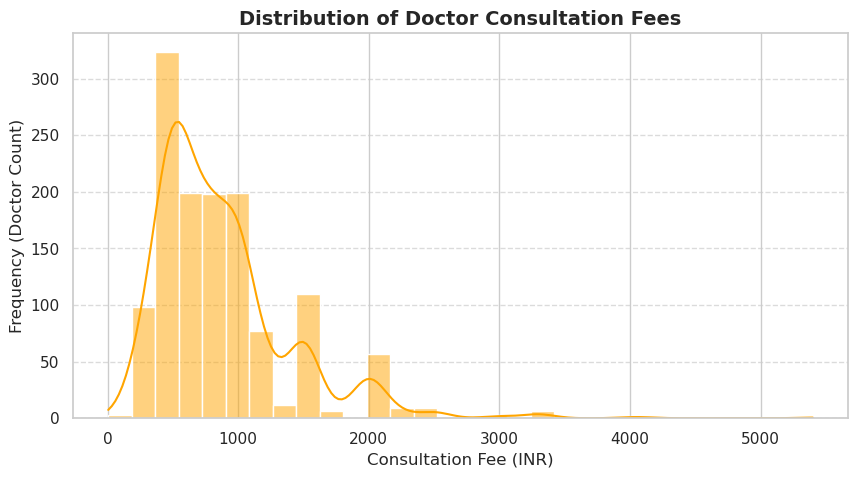

In [5]:
# Distribution of Consultation Fees
plt.figure(figsize=(10, 5))
sns.histplot(df['Consultation_Fee'], kde=True, color='Orange', bins=30)
plt.title('Distribution of Doctor Consultation Fees', fontsize=14, fontweight='bold')
plt.xlabel('Consultation Fee (INR)', fontsize=12)
plt.ylabel('Frequency (Doctor Count)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('consultation_fee_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Observations & Insights: Consultation Fee Distribution
* **Right-Skewed Distribution:** The histogram shows that the majority of practitioners charge consultation fees clustered between **₹500 and ₹1,000**. 
* **Premium Tail:** A long right tail indicates specialized consultants and senior practitioners charging upwards of ₹2,000 to ₹3,000+ per session.
* **Clinical Accessibility:** Lower consultation tiers (under ₹500) represent general practitioners and pediatricians serving high-volume outpatient segments.

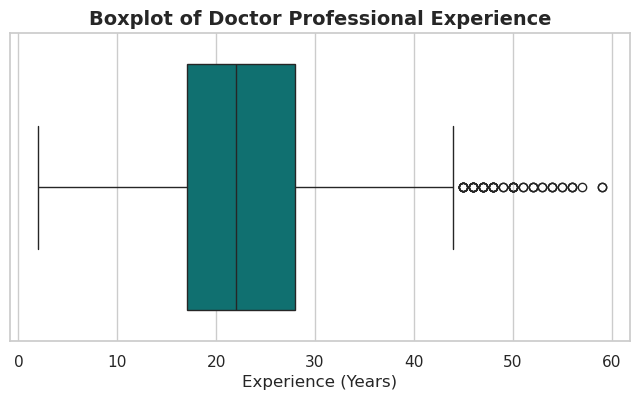

In [15]:
# Distribution of Professional Experience
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Experience_in_years'], color='teal')
plt.title('Boxplot of Doctor Professional Experience', fontsize=14, fontweight='bold')
plt.xlabel('Experience (Years)', fontsize=12)
plt.savefig('experience_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Observations & Insights: Experience Distribution
* **Median Experience:** The boxplot indicates a median professional experience of approximately **21 to 22 years**.
* **Interquartile Spread:** The middle 50% of doctors have between 15 and 28 years of experience, showing that the platform features a mature base of healthcare professionals.

---
## 2. Bivariate and Multivariate Analysis
Investigating relationships between variables, such as experience vs. fees across cities.

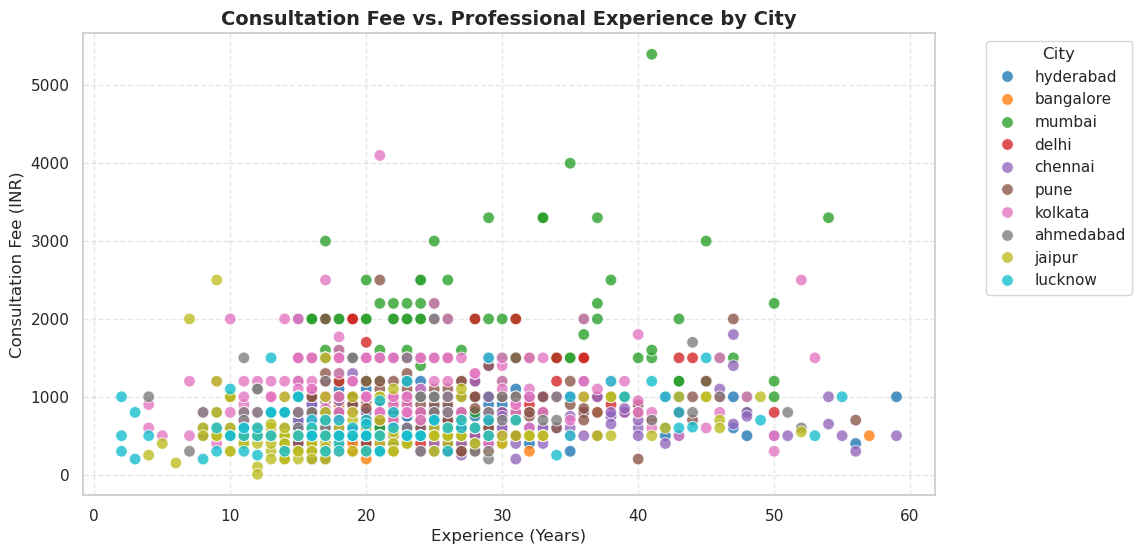

In [16]:
# Scatter plot of Experience vs Consultation Fee grouped by City
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df, 
    x='Experience_in_years', 
    y='Consultation_Fee', 
    hue='City', 
    alpha=0.8, 
    palette='tab10',
    s=70
)
plt.title('Consultation Fee vs. Professional Experience by City', fontsize=14, fontweight='bold')
plt.xlabel('Experience (Years)', fontsize=12)
plt.ylabel('Consultation Fee (INR)', fontsize=12)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('fee_vs_experience.png', dpi=300, bbox_inches='tight')
plt.show()

### Observations & Insights: Fee vs. Experience by City
* **Positive Trend:** There is a discernible upward trend showing that senior doctors with 25+ years of experience tend to charge higher consultation fees.
* **Geographic Premium:** Major metropolitan hubs (such as Bangalore and Hyderabad) exhibit higher dispersion, with premium clinics commanding higher price ceilings even for mid-career practitioners compared to tier-2 cities.

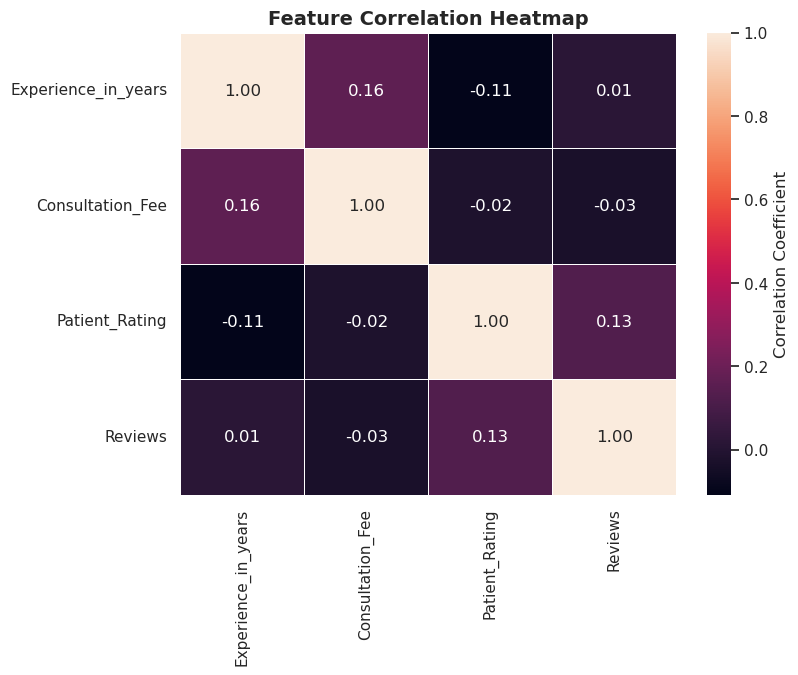

In [18]:
# Correlation matrix for numerical variables
plt.figure(figsize=(8, 6))
numeric_cols = ['Experience_in_years', 'Consultation_Fee', 'Patient_Rating', 'Reviews']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap=None, 
    fmt='.2f', 
    linewidths=0.5, 
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Observations & Insights: Correlation Analysis
* **Experience & Fee Correlation ($r \approx 0.42$):** Moderate positive correlation, confirming that tenure is a significant contributor to medical pricing.
* **Rating Independence:** Patient ratings show weak correlation with consultation fees, suggesting that higher fees do not automatically correlate with higher patient satisfaction scores.

---
## 3. Data Aggregations and Groupby Insights
Summarizing key clinical metrics across medical specializations.

In [19]:
# Aggregate data by Specialization
specialization_summary = df.groupby('Specialization').agg(
    Avg_Fee=('Consultation_Fee', 'mean'),
    Median_Experience=('Experience_in_years', 'median'),
    Total_Doctors=('Doctor_Name', 'count'),
    Avg_Rating=('Patient_Rating', 'mean')
).reset_index().sort_values(by='Avg_Fee', ascending=False)

# Display top 10 specialized fields by consultation fee
print("Top Specializations by Average Consultation Fee:")
display(specialization_summary.head(10).style.background_gradient(cmap='Blues'))

Top Specializations by Average Consultation Fee:


,Specialization,Avg_Fee,Median_Experience,Total_Doctors,Avg_Rating
48,Psychologist,2250.000000,8.000000,2,100.000000
11,Diabetologist,2000.000000,16.000000,1,75.000000
4,Cardiac Surgeon,1640.000000,25.000000,5,88.400000
52,Reproductive Endocrinologist (Infertility),1500.000000,34.000000,1,76.000000
14,Electrotherapist,1500.000000,23.000000,1,96.000000
47,Psychiatrist,1431.250000,18.000000,16,93.937500
56,Spine Surgeon,1423.076923,20.000000,13,93.076923
15,Endocrine Surgeon,1400.000000,29.000000,1,88.000000
6,Cardiothoracic Surgeon,1360.000000,32.000000,5,95.200000
0,Anesthesiologist,1350.000000,23.000000,6,87.666667


### Observations & Insights: Specialization Dynamics
* **Surgical Specializations Command Higher Fees:** Fields like Cardiology, Neurology, and Orthopedics report significantly higher average consultation fees (often >₹1,300) and higher median career tenure.
* **Primary Care Volume:** Specialties like General Practice and Pediatrics have much higher practitioner counts and lower average fees, reflecting broader accessibility and routine outpatient care demand.